<a href="https://colab.research.google.com/github/fidanismayilzada23/Data-Analytics-Google-Colab-Workbooks/blob/main/Global_Terrorism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import kagglehub

path = kagglehub.dataset_download("START-UMD/gtd")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'gtd' dataset.
Path to dataset files: /kaggle/input/gtd


In [40]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
os.listdir(path)


['globalterrorismdb_0718dist.csv']

In [41]:
df = pd.read_csv(os.path.join(path, "globalterrorismdb_0718dist.csv"), encoding="latin1")

/tmp/ipython-input-3392847333.py:1: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(path, "globalterrorismdb_0718dist.csv"), encoding="latin1")


In [42]:
#Checking the Size (Shape) of a DataFrame
df.shape

(181691, 135)

In [43]:
#Number of Rows in a DataFrame
len(df)

181691

In [44]:
#Handling Missing Values in a DataFrame
df.isnull().mean().sort_values(ascending=False)
threshold = 0.5
df = df.loc[:, df.isnull().mean() < threshold]
df = df.dropna(axis=1, how='all')

In [45]:
# Fill categorical
cat_fill = [
    'provstate','city','target1',
    'natlty1_txt','targsubtype1_txt',
    'weapsubtype1_txt'
]
df[cat_fill] = df[cat_fill].fillna('Unknown')

# Fill numeric
df['nkill'] = df['nkill'].fillna(0)
df['nwound'] = df['nwound'].fillna(0)
df['nperps'] = df['nperps'].fillna(0)
df['nperpcap'] = df['nperpcap'].fillna(0)

df = df.drop(columns=[
    'summary','corp1','weapdetail',
    'nkillus','nkillter','nwoundus','nwoundte',
    'scite1'
])


In [46]:
#View the First Rows of a DataFrame
df.head(3)

,eventid,iyear,imonth,iday,extended,country,country_txt,region,region_txt,provstate,...,weapsubtype1_txt,nkill,nwound,property,ishostkid,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
0,197000000001,1970,7,2,0,58,Dominican Republic,2,Central America & Caribbean,Unknown,...,Unknown,1.0,0.0,0,0.0,PGIS,0,0,0,0
1,197000000002,1970,0,0,0,130,Mexico,1,North America,Federal,...,Unknown,0.0,0.0,0,1.0,PGIS,0,1,1,1
2,197001000001,1970,1,0,0,160,Philippines,5,Southeast Asia,Tarlac,...,Unknown,1.0,0.0,0,0.0,PGIS,-9,-9,1,1


In [47]:
#Filling Missing Values and Dropping Columns
df['specificity'] = df['specificity'].fillna(df['specificity'].mode()[0])
df['doubtterr'] = df['doubtterr'].fillna(0)
df['multiple'] = df['multiple'].fillna(0)
df = df.drop(columns=['targsubtype1'])
df = df.drop(columns=['natlty1'])
df['guncertain1'] = df['guncertain1'].fillna(0)
df = df.drop(columns=['claimed'])
df = df.drop(columns=['weapsubtype1'])
df['ishostkid'] = df['ishostkid'].fillna(0)


In [48]:
#Check Remaining Missing Values
df.isnull().sum()

,0
eventid,0
iyear,0
imonth,0
iday,0
extended,0
country,0
country_txt,0
region,0
region_txt,0
provstate,0


In [49]:
#DataFrame Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 46 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   eventid           181691 non-null  int64  
 1   iyear             181691 non-null  int64  
 2   imonth            181691 non-null  int64  
 3   iday              181691 non-null  int64  
 4   extended          181691 non-null  int64  
 5   country           181691 non-null  int64  
 6   country_txt       181691 non-null  object 
 7   region            181691 non-null  int64  
 8   region_txt        181691 non-null  object 
 9   provstate         181691 non-null  object 
 10  city              181691 non-null  object 
 11  latitude          177135 non-null  float64
 12  longitude         177134 non-null  float64
 13  specificity       181691 non-null  float64
 14  vicinity          181691 non-null  int64  
 15  crit1             181691 non-null  int64  
 16  crit2             18

In [50]:
#Compute Correlation Between Numeric Columns
df.corr(numeric_only=True)

,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,nperpcap,weaptype1,nkill,nwound,property,ishostkid,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
eventid,1.000000,0.999996,0.002706,0.018336,0.091761,-0.135039,0.401371,0.166886,0.003907,0.030634,...,0.083158,-0.011716,0.021263,0.017492,-0.278927,-0.009890,-0.143600,-0.133252,-0.077852,-0.175605
iyear,0.999996,1.000000,0.000139,0.018254,0.091754,-0.135023,0.401384,0.166933,0.003917,0.030619,...,0.083120,-0.011737,0.021252,0.017484,-0.278916,-0.009904,-0.143601,-0.133253,-0.077847,-0.175596
imonth,0.002706,0.000139,1.000000,0.005497,-0.000468,-0.006305,-0.002999,-0.015978,-0.003880,0.003621,...,0.015034,0.007863,0.004031,0.003178,-0.005816,0.003397,-0.002302,-0.002034,-0.002554,-0.006336
iday,0.018336,0.018254,0.005497,1.000000,-0.004700,0.003468,0.009710,0.003423,-0.002285,-0.007002,...,0.001426,-0.003019,-0.003225,-0.001082,-0.003903,0.004077,-0.001540,-0.001621,-0.002027,-0.001199
extended,0.091761,0.091754,-0.000468,-0.004700,1.000000,-0.020466,0.038389,-0.024749,0.000523,0.057870,...,0.007356,0.207802,0.014586,-0.010175,-0.002096,0.326368,0.071768,0.075147,0.027335,0.080767
country,-0.135039,-0.135023,-0.006305,0.003468,-0.020466,1.000000,0.148597,0.178567,-0.000269,-0.084597,...,-0.033915,-0.023708,-0.014383,-0.006351,0.032051,-0.013425,0.069904,0.067564,0.207281,0.153118
region,0.401371,0.401384,-0.002999,0.009710,0.038389,0.148597,1.000000,0.309274,0.004351,-0.084194,...,0.096364,0.013257,0.043113,0.019211,-0.183279,-0.022747,-0.082584,-0.071917,0.043139,-0.047900
latitude,0.166886,0.166933,-0.015978,0.003423,-0.024749,0.178567,0.309274,1.000000,0.001463,-0.018811,...,-0.042711,-0.011710,-0.013170,0.015920,-0.084537,-0.022529,-0.099827,-0.094470,0.097652,-0.041530
longitude,0.003907,0.003917,-0.003880,-0.002285,0.000523,-0.000269,0.004351,0.001463,1.000000,0.001065,...,-0.000196,0.001582,-0.000587,0.000205,-0.001231,0.000295,0.002272,0.002268,0.000371,0.002497
specificity,0.030634,0.030619,0.003621,-0.007002,0.057870,-0.084597,-0.084194,-0.018811,0.001065,1.000000,...,0.023987,0.064586,0.020225,-0.015405,0.028107,0.016084,0.073015,0.071327,-0.019199,0.061384


In [51]:
#Countries with the most incidents
df["country_txt"].value_counts().head(10)

,count
country_txt,
Iraq,24636
Pakistan,14368
Afghanistan,12731
India,11960
Colombia,8306
Philippines,6908
Peru,6096
El Salvador,5320
United Kingdom,5235


In [52]:
#Region × attack type
pd.crosstab(df["region_txt"], df["attacktype1_txt"])

attacktype1_txt,Armed Assault,Assassination,Bombing/Explosion,Facility/Infrastructure Attack,Hijacking,Hostage Taking (Barricade Incident),Hostage Taking (Kidnapping),Unarmed Assault,Unknown
region_txt,,,,,,,,,
Australasia & Oceania,51,36,75,71,3,6,13,11,16
Central America & Caribbean,4361,1254,3239,403,26,187,501,19,354
Central Asia,116,115,235,20,8,2,45,5,17
East Asia,117,55,330,200,18,3,14,42,23
Eastern Europe,1274,400,2766,260,26,21,220,62,115
Middle East & North Africa,9273,4206,30908,1115,138,100,2666,177,1891
North America,448,255,1534,906,18,67,123,73,32
South America,3875,2745,9039,803,67,234,1414,47,754
South Asia,11404,4301,21246,2189,93,120,3277,323,2021


In [53]:
#Aggregate Data by Year
yearly = df.groupby('iyear').agg(
    attacks=('eventid','count'),
    killed=('nkill','sum'),
    wounded=('nwound','sum')
).reset_index()


Data Visualization Summary for the Terrorism Dataset

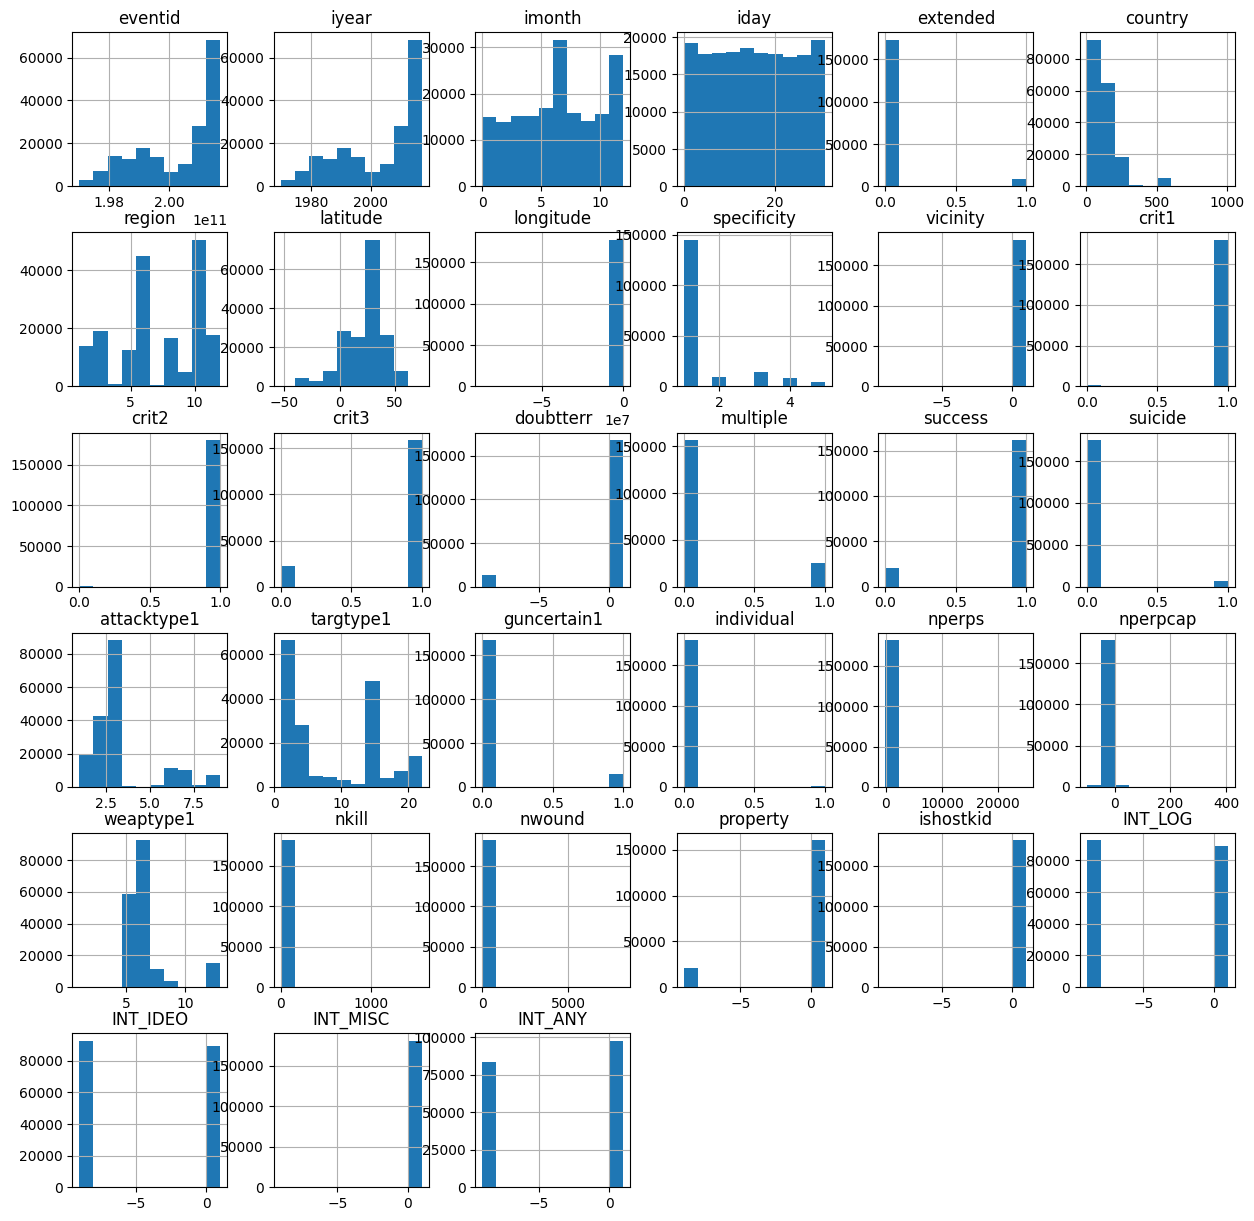

In [54]:
#Visualize Distribution of All Numeric Columns
df.hist(figsize=(15,15));

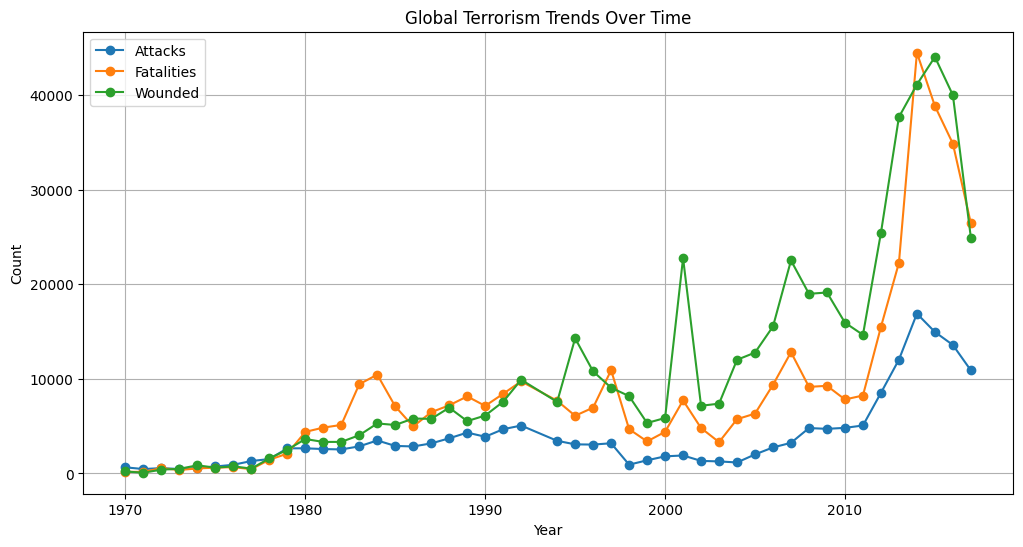

In [55]:
# Plot Annual Terrorism Trends
yearly_attacks = df.groupby('iyear')['eventid'].count()

yearly_kill = df.groupby('iyear')['nkill'].sum()

yearly_wound = df.groupby('iyear')['nwound'].sum()

plt.figure(figsize=(12,6))
plt.plot(yearly_attacks.index, yearly_attacks.values, label='Attacks', marker='o')
plt.plot(yearly_kill.index, yearly_kill.values, label='Fatalities', marker='o')
plt.plot(yearly_wound.index, yearly_wound.values, label='Wounded', marker='o')
plt.title('Global Terrorism Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()

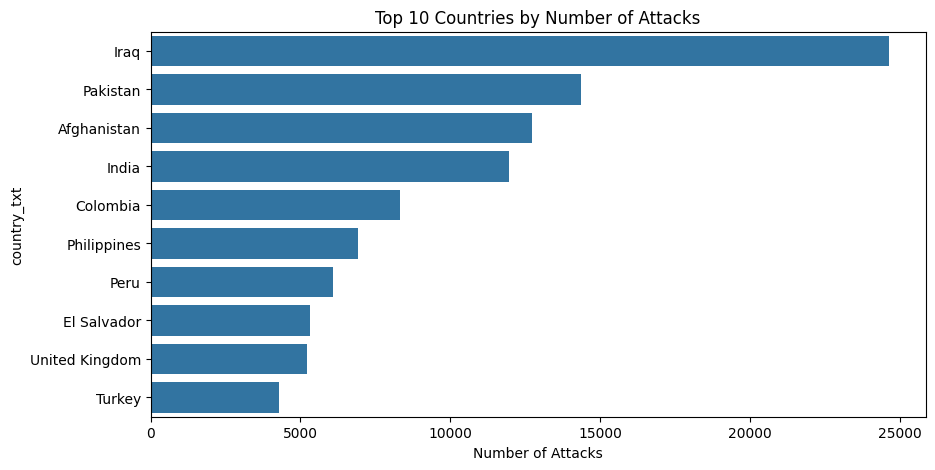

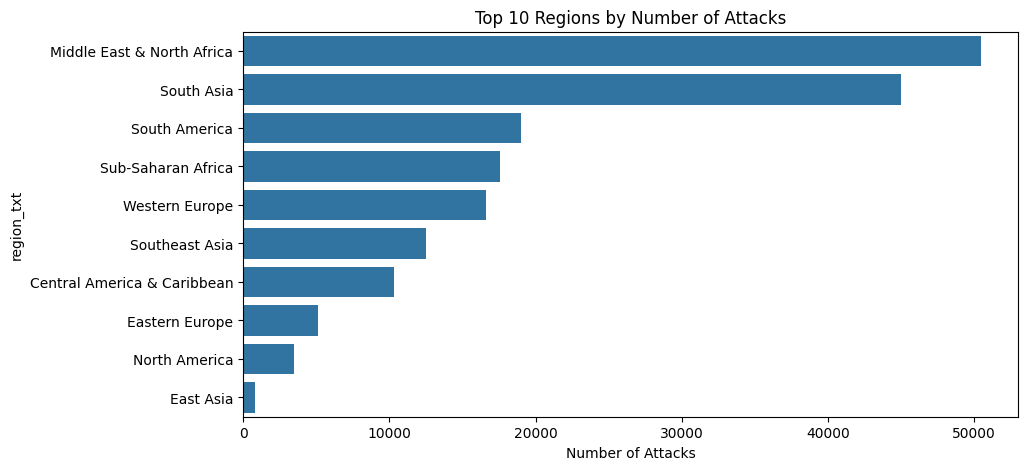

In [56]:
# Top 10 countries
top_countries = df['country_txt'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries by Number of Attacks')
plt.xlabel('Number of Attacks')
plt.show()

# Top 10 regions
top_regions = df['region_txt'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_regions.values, y=top_regions.index)
plt.title('Top 10 Regions by Number of Attacks')
plt.xlabel('Number of Attacks')
plt.show()


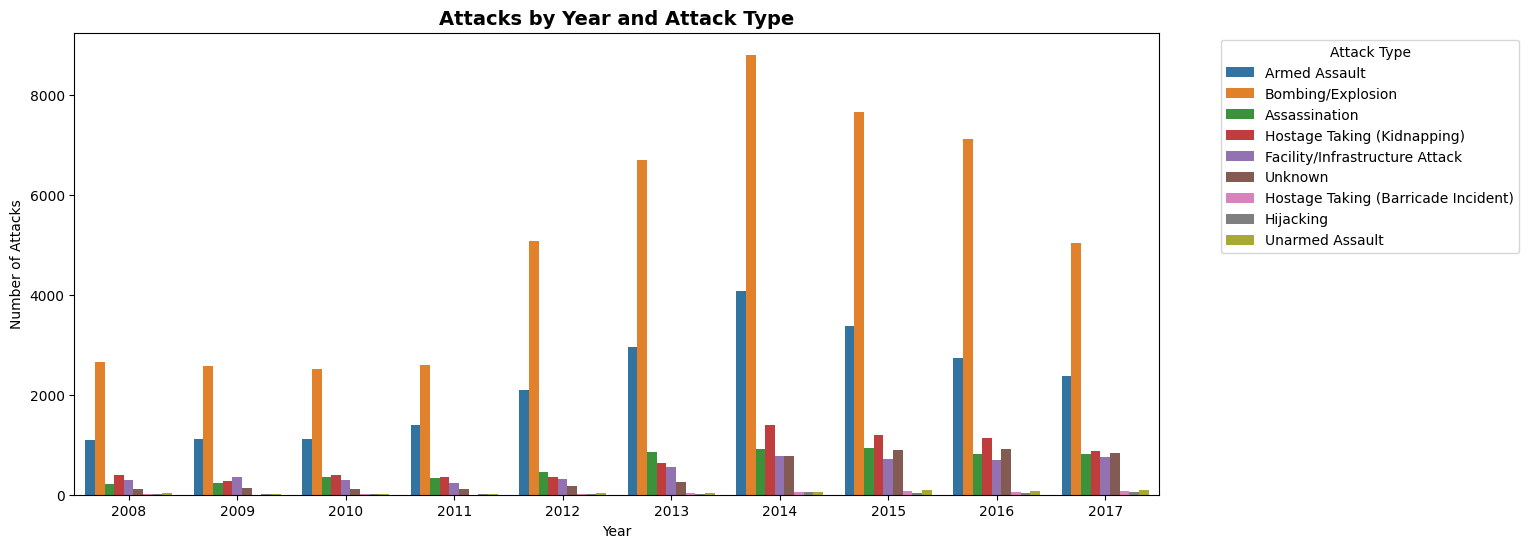

In [57]:
#Visualize Attack Types by Year (2008 and Later)
recent_df = df[df['iyear'] >= 2008]

plt.figure(figsize=(14,6))
sns.countplot(
    data=recent_df,
    x='iyear',
    hue='attacktype1_txt'
)
plt.title('Attacks by Year and Attack Type', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

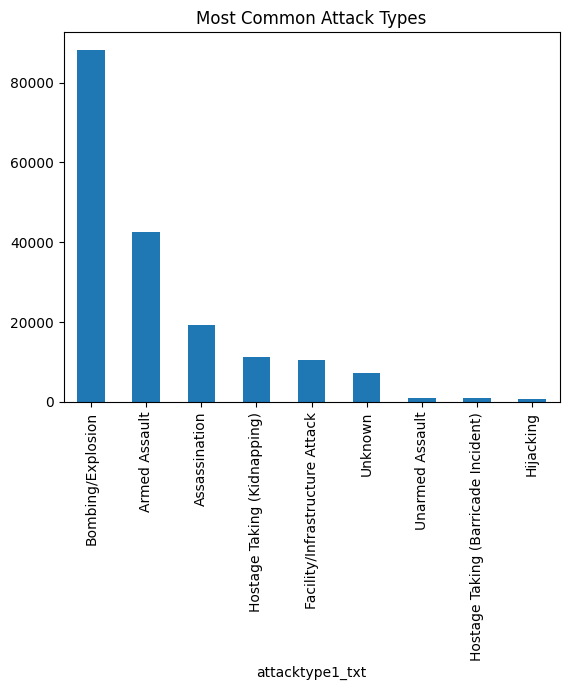

In [58]:
#p 10 Most Common Attack Types
df['attacktype1_txt'].value_counts().head(10).plot(kind='bar')
plt.title('Most Common Attack Types')
plt.show()

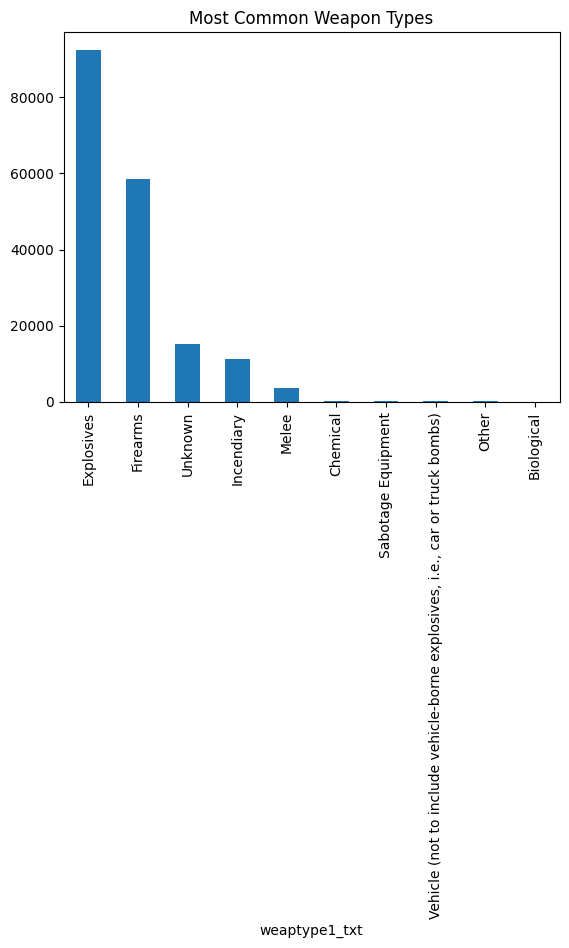

In [59]:
#Top 10 Most Common Weapon Types
df['weaptype1_txt'].value_counts().head(10).plot(kind='bar')
plt.title('Most Common Weapon Types')
plt.show()

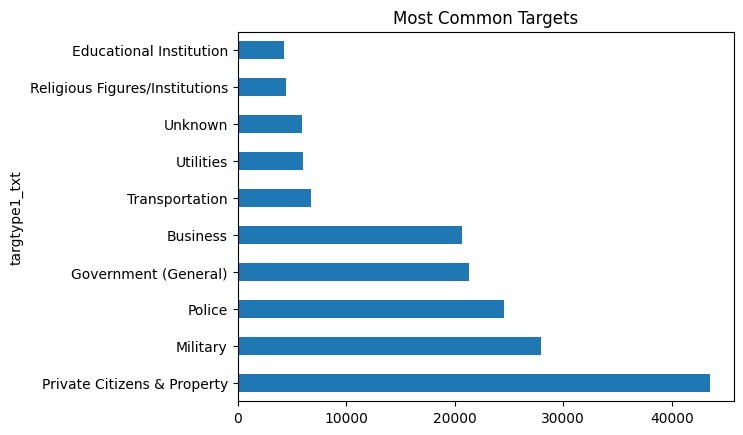

In [60]:
#Top 10 Most Common Target Types
df['targtype1_txt'].value_counts().head(10).plot(kind='barh')
plt.title('Most Common Targets')
plt.show()

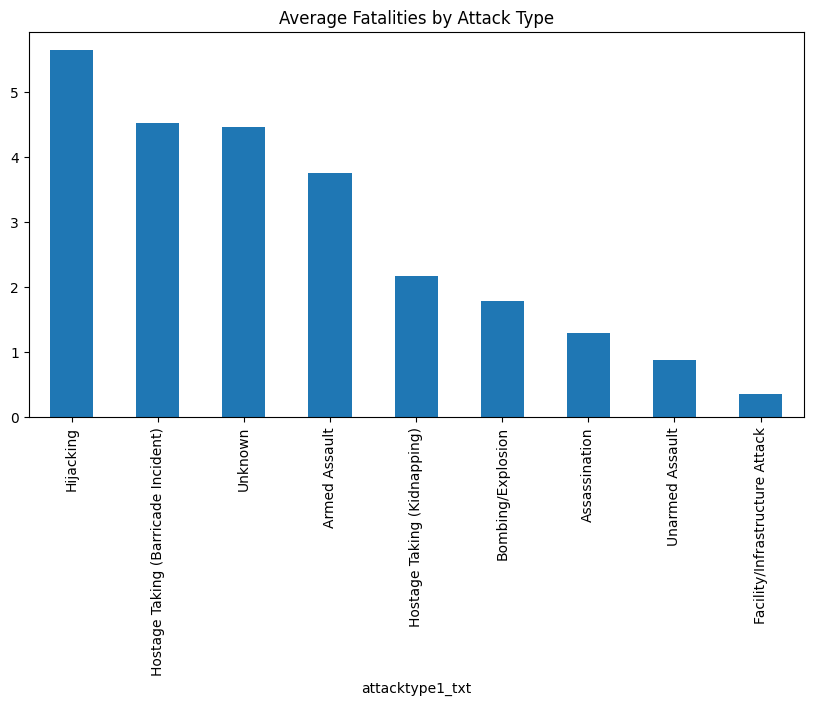

In [61]:
#Top 10 Attack Types by Lethality
lethality = df.groupby('attacktype1_txt')['nkill'].mean().sort_values(ascending=False).head(10)

lethality.plot(kind='bar', figsize=(10,5))
plt.title('Average Fatalities by Attack Type')
plt.show()


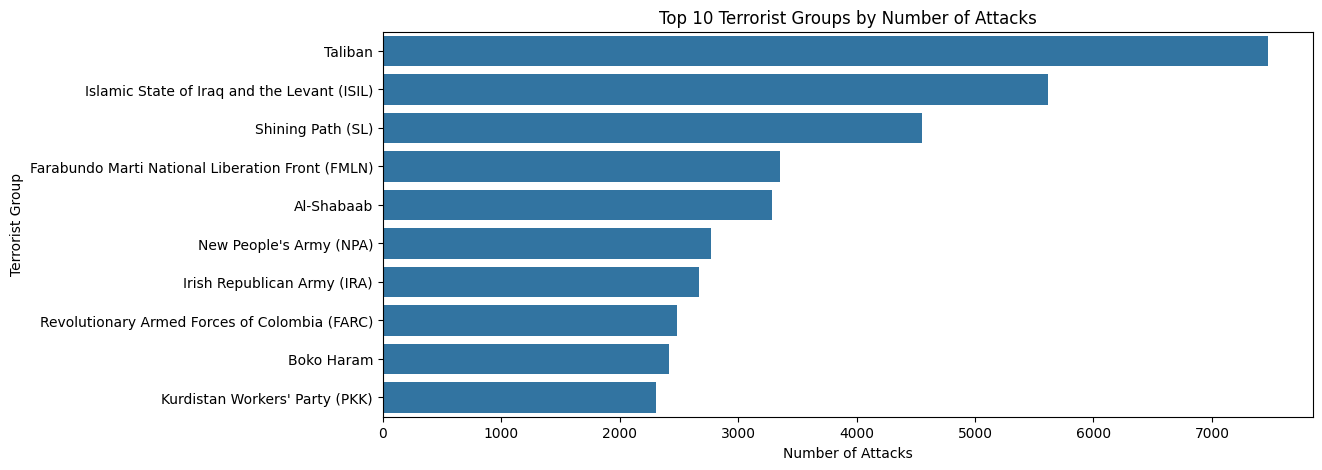

In [62]:
filtered_df = df[~df['gname'].isin(['Unknown'])]

top_groups = filtered_df['gname'].value_counts().head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_groups.values, y=top_groups.index)
plt.title('Top 10 Terrorist Groups by Number of Attacks')
plt.xlabel('Number of Attacks')
plt.ylabel('Terrorist Group')
plt.show()


In [63]:
#Top 10 Most Frequent Known Perpetrator Groups
filtered_df = df[~df['gname'].str.strip().str.lower().eq('unknown')]
filtered_df['gname'].value_counts().head(10)

,count
gname,
Taliban,7478
Islamic State of Iraq and the Levant (ISIL),5613
Shining Path (SL),4555
Farabundo Marti National Liberation Front (FMLN),3351
Al-Shabaab,3288
New People's Army (NPA),2772
Irish Republican Army (IRA),2671
Revolutionary Armed Forces of Colombia (FARC),2487
Boko Haram,2418


In [64]:
df['region_year_count'] = df.groupby(['region_txt', 'iyear'])['eventid'].transform('count')

In [65]:
country_counts = df['country_txt'].value_counts()
df['country_attack_count'] = df['country_txt'].map(country_counts)

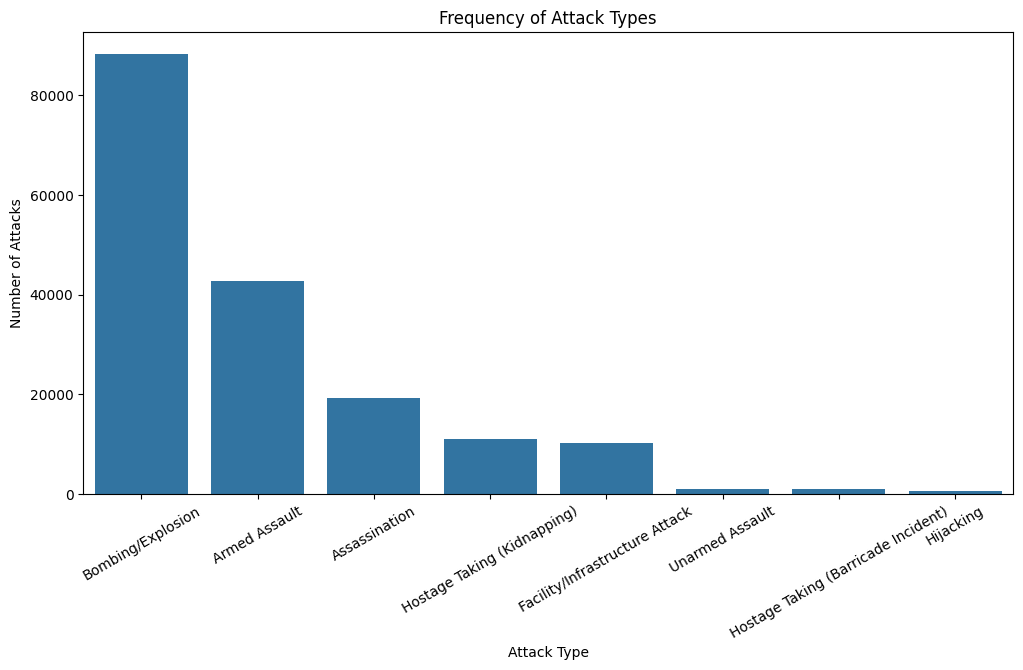

In [66]:
#Frequency of Known Attack Types
attack_counts = (df.loc[~df['attacktype1_txt'].str.strip().str.lower().eq('unknown'),'attacktype1_txt'].value_counts())

plt.figure(figsize=(12,6))
sns.barplot(x=attack_counts.index, y=attack_counts.values)
plt.title('Frequency of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=30)
plt.show()


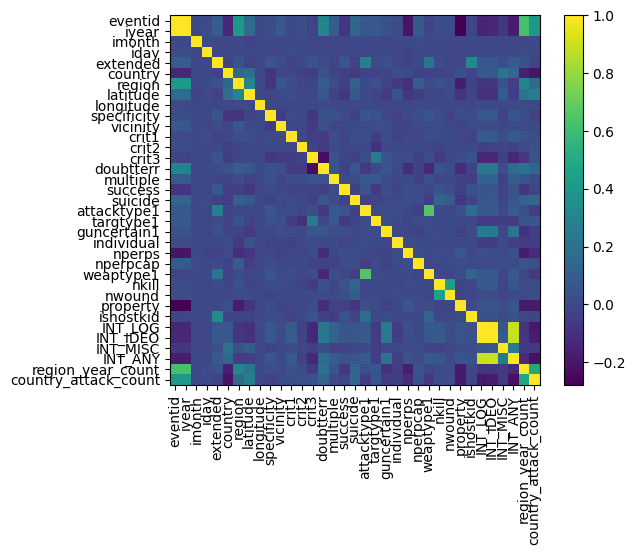

In [67]:
#Visualize Correlation Matrix as Heatmap
corr = df.corr(numeric_only=True)
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr)),corr.columns,rotation=90)
plt.yticks(range(len(corr)),corr.columns);


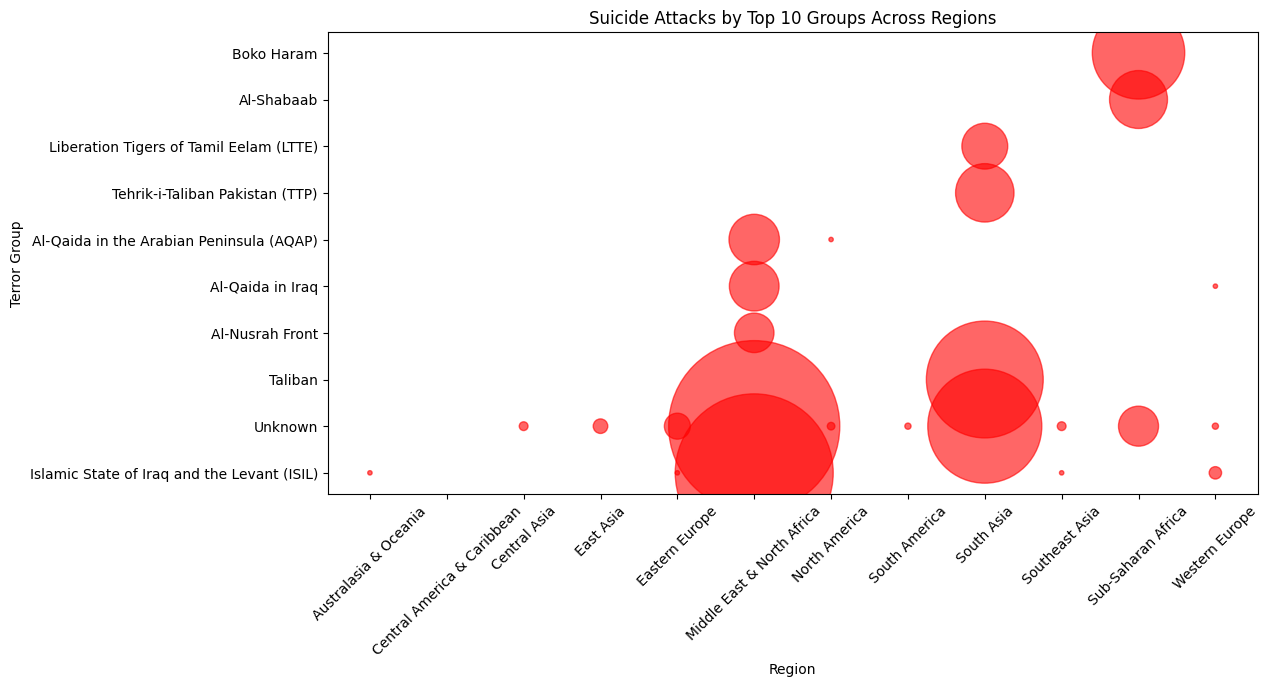

In [68]:
#Suicide Attacks by Top 10 Terror Groups Across Regions
group_region = df.groupby(['region_txt','gname'])['suicide'].sum().reset_index()
top_groups = group_region.groupby('gname')['suicide'].sum().sort_values(ascending=False).head(10).index
plot_data = group_region[group_region['gname'].isin(top_groups)]

plt.figure(figsize=(12,6))
plt.scatter(
    x=plot_data['region_txt'],
    y=plot_data['gname'],
    s=plot_data['suicide']*10,
    alpha=0.6,
    color='red')
plt.xticks(rotation=45)
plt.title("Suicide Attacks by Top 10 Groups Across Regions")
plt.xlabel("Region")
plt.ylabel("Terror Group")
plt.show()


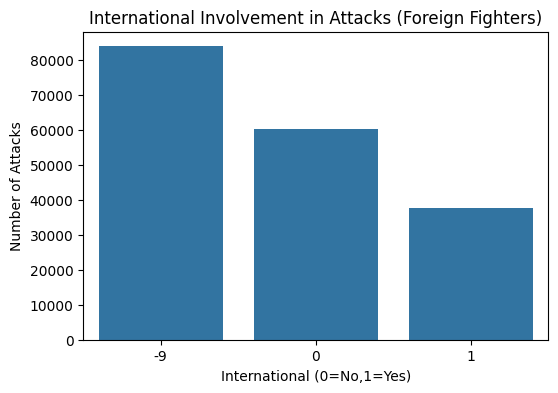

In [69]:
# International involvement (foreign fighters)
plt.figure(figsize=(6,4))
sns.countplot(x='INT_ANY', data=df)
plt.title('International Involvement in Attacks (Foreign Fighters)')
plt.xlabel('International (0=No,1=Yes)')
plt.ylabel('Number of Attacks')
plt.show()


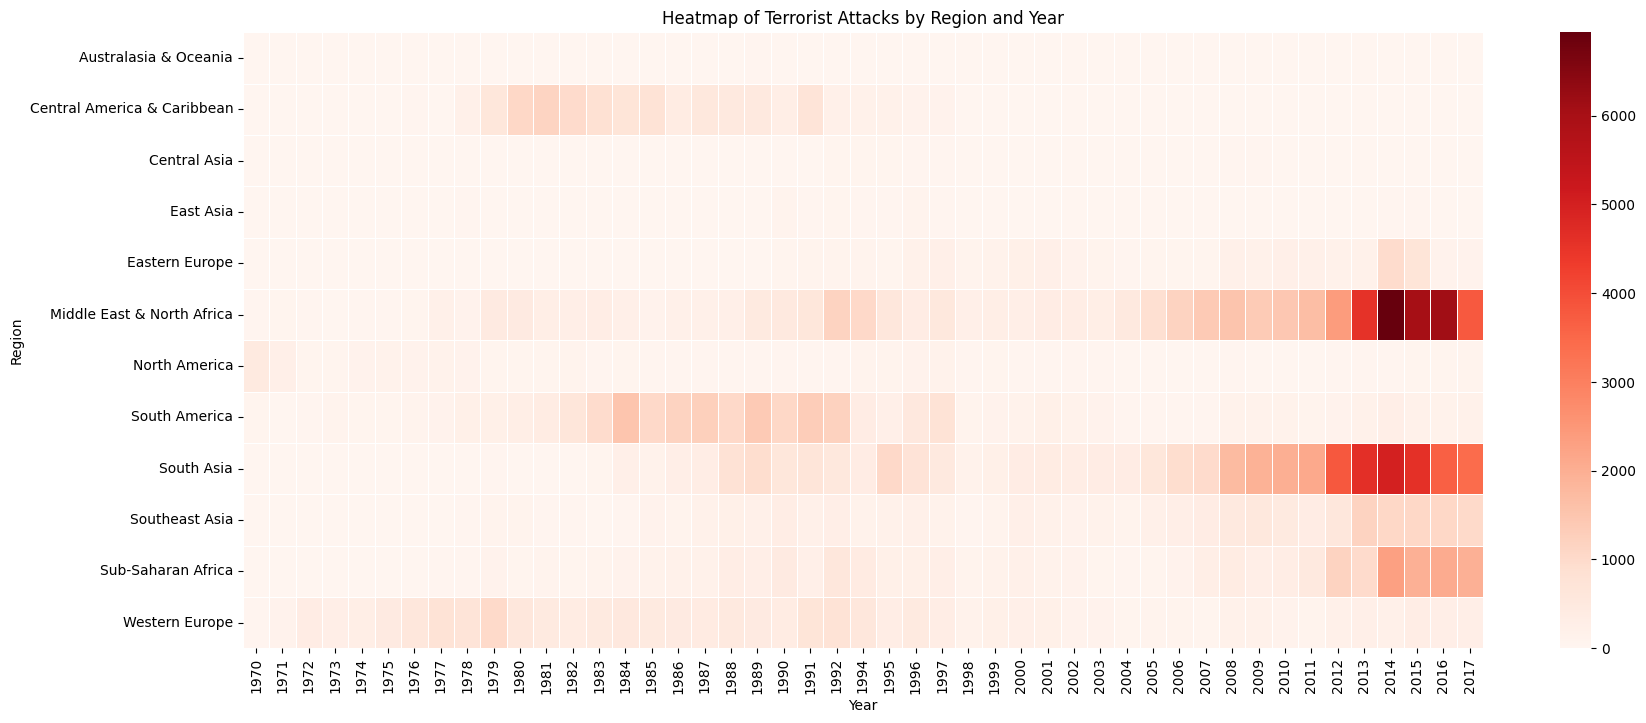

In [70]:
pivot_region_year = df.pivot_table(index='region_txt', columns='iyear', values='eventid', aggfunc='count', fill_value=0)
plt.figure(figsize=(20,8))
sns.heatmap(pivot_region_year, cmap='Reds', linewidths=0.5)
plt.title('Heatmap of Terrorist Attacks by Region and Year')
plt.xlabel('Year')
plt.ylabel('Region')
plt.show()

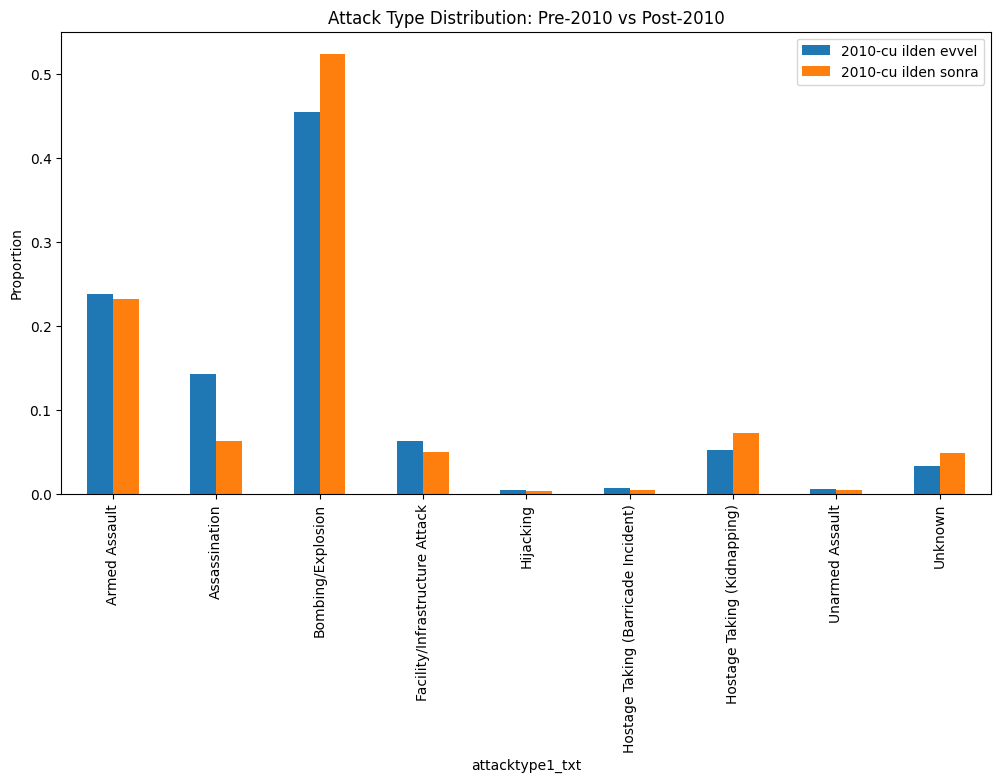

In [71]:
evvel = df[df['iyear'] <= 2010]
sonra = df[df['iyear'] > 2010]

pre_attacks = evvel['attacktype1_txt'].value_counts(normalize=True)
post_attacks = sonra['attacktype1_txt'].value_counts(normalize=True)

df_compare = pd.DataFrame({'2010-cu ilden evvel': pre_attacks, '2010-cu ilden sonra': post_attacks}).fillna(0)
df_compare.plot(kind='bar', figsize=(12,6))
plt.title('Attack Type Distribution: Pre-2010 vs Post-2010')
plt.ylabel('Proportion')
plt.show()


Global Terrorism Heatmap

In [72]:
import folium
from folium.plugins import HeatMap

geo_df = df.dropna(subset=['latitude','longitude'])
map = folium.Map(location=[20,0], zoom_start=2)
heat_data = list(zip(geo_df['latitude'], geo_df['longitude']))
HeatMap(heat_data, radius=8, blur=4).add_to(map)
map
